In [249]:
import numpy as np
import pandas as pd

In [250]:
np.random.seed(42)

In [251]:
def relu(x):
    return np.maximum(0, x)

In [252]:
def relu_derivative(x):
    return (x > 0).astype(float)

In [253]:
def softmax(x):
    exp = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

In [254]:
def cross_entropy(y_pred, y_true):
    m = y_true.shape[0]
    return -np.sum(y_true * np.log(y_pred + 1e-8)) / m

In [255]:
def tanh_derivative(x):
    return 1 - np.tanh(x)**2

In [256]:
X = np.random.randint(0, 255, size=(10000, 20, 30))

In [257]:
X.shape

(10000, 20, 30)

In [258]:
X = X.reshape(10000, 600)
X = X.T

In [259]:
Y = np.random.randint(0, output_neurons, size=(10000,))

In [260]:
Y.shape

(10000,)

In [261]:
m = X.shape[1]

In [262]:
input_neurons = 600
hidden_neurons = 128
output_neurons = 10

In [263]:
def initialize_parameters():

    W1 = np.random.randn(hidden_neurons, input_neurons) * 0.01
    b1 = np.zeros((hidden_neurons, 1))

    W2 = np.random.randn(output_neurons, hidden_neurons) * 0.01
    b2 = np.zeros((output_neurons, 1))

    return W1, b1, W2, b2

In [264]:
def one_hot(Y, num_classes):

    one_hot_Y = np.zeros((num_classes, Y.size))

    one_hot_Y[Y, np.arange(Y.size)] = 1

    return one_hot_Y

In [265]:
one_hot(Y, 10)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [266]:
def forward_propagation(X, W1, b1, W2, b2):

    Z1 = np.dot(W1, X) + b1
    A1 = np.tanh(Z1)

    Z2 = np.dot(W2, A1) + b2
    A2 = softmax(Z2)

    cache = (Z1, A1, Z2, A2)

    return A2, cache

In [267]:
def backward_propagation(X, Y, cache, W2):

    Z1, A1, Z2, A2 = cache

    one_hot_Y = one_hot(Y, output_neurons)

    # Output Layer
    dZ2 = A2 - one_hot_Y

    dW2 = (1/m) * np.dot(dZ2, A1.T)

    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

    # Hidden Layer
    dZ1 = np.dot(W2.T, dZ2) * tanh_derivative(Z1)

    dW1 = (1/m) * np.dot(dZ1, X.T)

    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

    return dW1, db1, dW2, db2

In [268]:
def compute_loss(A2, Y):

    one_hot_Y = one_hot(Y, output_neurons)

    loss = -np.sum(one_hot_Y * np.log(A2 + 1e-8)) / m

    return loss

In [269]:
def update_parameters(W1, b1, W2, b2,
                      dW1, db1, dW2, db2,
                      learning_rate):

    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1

    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    return W1, b1, W2, b2

In [270]:
def train_network(learning_rate, epochs):

    # Initialize Parameters
    W1, b1, W2, b2 = initialize_parameters()

    losses = []

    for epoch in range(epochs):

        # Forward Propagation
        A2, cache = forward_propagation(X, W1, b1, W2, b2)

        # Compute Loss
        loss = compute_loss(A2, Y)

        losses.append(loss)

        # Backward Propagation
        dW1, db1, dW2, db2 = backward_propagation(X, Y, cache, W2)

        # Gradient Descent
        W1, b1, W2, b2 = update_parameters(
            W1, b1, W2, b2,
            dW1, db1, dW2, db2,
            learning_rate
        )

    return losses

In [271]:
import matplotlib.pyplot as plt

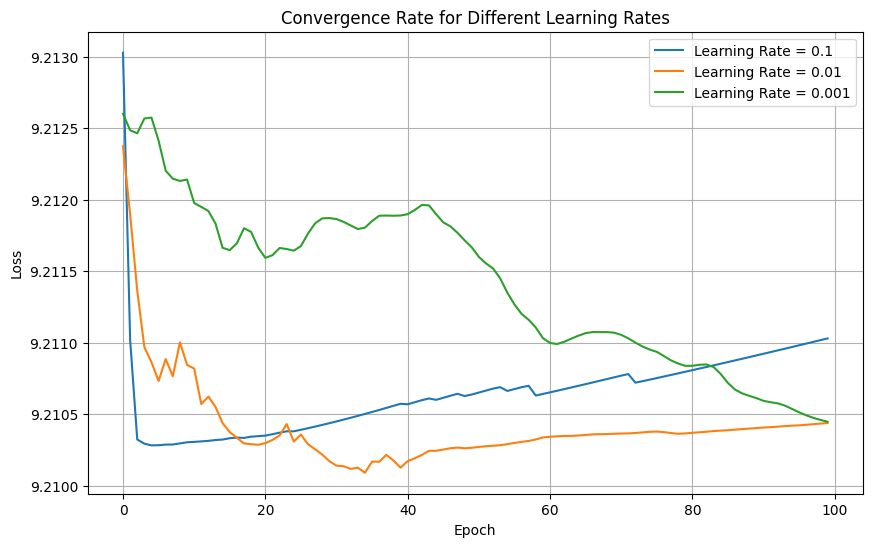

In [273]:
learning_rates = [0.1, 0.01, 0.001]

epochs = 100

plt.figure(figsize=(10,6))

for lr in learning_rates:

    losses = train_network(lr, epochs)

    plt.plot(range(epochs),
             losses,
             label=f"Learning Rate = {lr}")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Convergence Rate for Different Learning Rates")

plt.legend()

plt.grid(True)

plt.show()


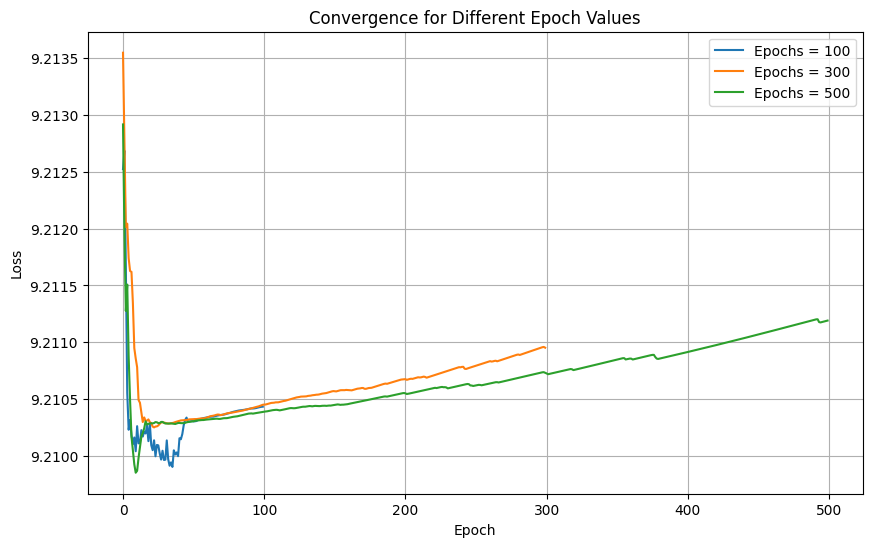

In [274]:
epoch_values = [100, 300, 500]

learning_rate = 0.01

plt.figure(figsize=(10,6))

for ep in epoch_values:

    losses = train_network(learning_rate, ep)

    plt.plot(range(ep),
             losses,
             label=f"Epochs = {ep}")

# ---------------------------------------------------------
# PLOT SETTINGS
# ---------------------------------------------------------

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Convergence for Different Epoch Values")

plt.legend()

plt.grid(True)

plt.show()